## Regresión lineal MLE con Funciones de Base Radial (RBF)

**Objetivo**: Ajustar un modelo de regresión no lineal usando funciones de base radial Gaussiana.

1. Generación de Datos Sintéticos
**Modelo verdadero**:
$ [ y(x) = \sin(2\pi x) ]$

**Observaciones**:
$ [ t = y(x) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \beta^{-1}) ]$
 donde $(\beta = 1/\sigma^2)$ es la precisión del ruido.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Configuración inicial
np.random.seed(10**4)  # Semilla para reproducibilidad
N_tot = 100            # Total de puntos de datos
sigma2 = 0.01          # Varianza del ruido
beta = 1/sigma2        # Precisión
betaInv = 1/beta       # Inversa de la precisión

# Generar datos
x_tot = np.linspace(0, 1, N_tot)
y_tot = np.sin(2*np.pi*x_tot)
t_tot = y_tot + np.sqrt(1/beta)*np.random.randn(N_tot)


2. División Train/Test
**Entrenamiento**: 10 puntos (10% de los datos).

**Test**: 90 puntos restantes.


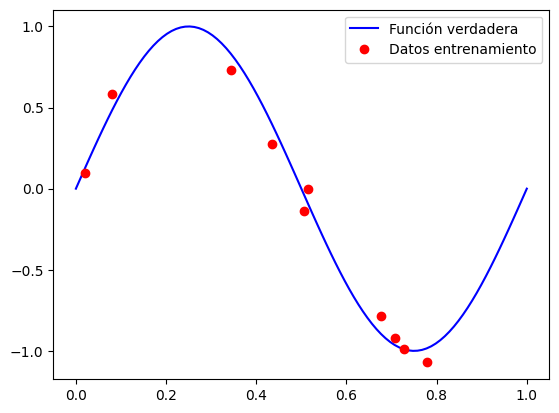

In [2]:
# Selección aleatoria de índices
index = np.random.permutation(N_tot)
N = 10  # Tamaño del conjunto de entrenamiento

# Datos de entrenamiento
x = x_tot[index[:N]]
t = t_tot[index[:N]]

# Datos de test (no usados en este ejemplo)
x_test = x_tot[index[N:]]
t_test = t_tot[index[N:]]

# Visualización
fig, ax = plt.subplots()
ax.plot(x_tot, y_tot, 'b', label='Función verdadera')
ax.plot(x, t, '.r', markersize=12, label='Datos entrenamiento')
ax.legend()
plt.show()

3. Diseño de Funciones de Base Radial (RBF)

**Matriz de diseño $(\Phi)$**:
$ [ \Phi(x) = \left[1, \exp\left(-\frac{(x-\mu_1)^2}{2s^2}\right), \dots, \exp\left(-\frac{(x-\mu_{M-1})^2}{2s^2}\right)\right]]$

$ (\mu_j)$: Centros espaciados uniformemente en [0, 1].

$(s^2 = 0.05 \cdot \Delta\mu)$: Ancho de las bases.

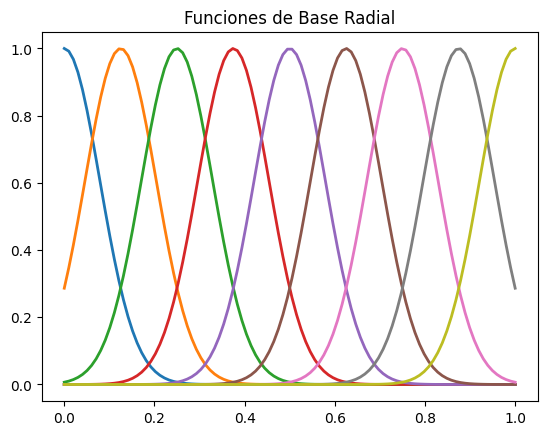

In [7]:
M = 10  # Número de funciones de base (incluyendo el término de bias)

# Centros de las RBF (excluyendo el bias)
mu = np.linspace(0, 1, M-1)
aux = np.diff(mu)
s2 = 0.05*aux[0]  # Ancho de las bases

PHI_tot = np.zeros((N_tot, M))
PHI_tot[:, 0] = np.ones(N_tot)
# Matriz de diseño para todos los puntos
for i in range(1, M):
    PHI_tot[:, i] = np.exp(-(x_tot - mu[i-1])**2/(2*s2))

# Visualización de las bases
fig, ax = plt.subplots()
ax.plot(x_tot, PHI_tot[:, 1:], linewidth=2)
ax.set_title('Funciones de Base Radial')
plt.show()

4. Solución de Máxima Verosimilitud (MLE)

**Modelo lineal**:
$[ \mathbf{t} = \Phi\mathbf{w} + \epsilon ]$

**Solución MLE**:
$[ \mathbf{w}_{\text{ML}} = (\Phi^T\Phi)^{-1}\Phi^T\mathbf{t}
]$

In [11]:
# Construir matriz de diseño para entrenamiento
PHI = np.ones((N, M))
for i in range(1, M):
    PHI[:, i] = np.exp(-(x - mu[i-1])**2/(2*s2))

# Calcular pesos óptimos
wML = np.linalg.solve(PHI.T @ PHI, PHI.T @ t[:, np.newaxis])

5. Predicción y Visualización

**Predicción**:
$[ \hat{y}(x) = \Phi(x)\mathbf{w}_{\text{ML}} ]$

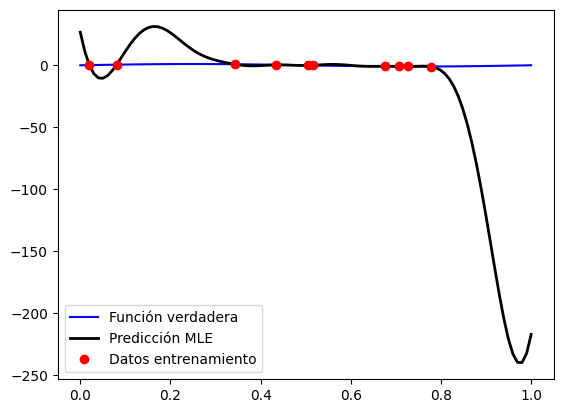

In [12]:
# Predecir en todos los puntos
y_hat = PHI_tot @ wML

# Visualización
fig, ax = plt.subplots()
ax.plot(x_tot, y_tot, 'b', label='Función verdadera')
ax.plot(x_tot, y_hat, 'k', linewidth=2, label='Predicción MLE')
ax.plot(x, t, '.r', markersize=12, label='Datos entrenamiento')
ax.legend()
plt.show()